In [1]:
import warnings
warnings.filterwarnings("ignore")

# Gaussian Mixture Model

GMM models the normal distribution as a mixture of K Gaussians. Compared to KDE it is more scalable and can capture multimodal distributions. We use 3 components with diagonal covariance to avoid numerical instabilities. The threshold and evaluation metric are the same as KDE.

In [2]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import os
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

with open("preprocessing.pkl", "rb") as f:
    prep = pickle.load(f)

features = prep["features"]
all_files = prep["all_files"]

def train_and_evaluate_gmm(fpath, features, n_components=3):
    df = pd.read_csv(fpath, sep=";")
    df_normal = df[df["anomaly"] == 0]

    scaler = StandardScaler()
    X_train = scaler.fit_transform(df_normal[features].values)

    gmm = GaussianMixture(n_components=n_components, random_state=42,
                          n_init=5, covariance_type="diag")
    gmm.fit(X_train)

    scores_train = gmm.score_samples(X_train)
    threshold = np.percentile(scores_train, 5)

    X_all = scaler.transform(df[features].values)
    scores_all = gmm.score_samples(X_all)

    first_real = df[df["anomaly"] == 1].index[0]
    detections = np.where(scores_all < threshold)[0]
    detections_after = detections[detections >= first_real]

    if len(detections_after) > 0:
        first_detected = detections_after[0]
        delay = first_detected - first_real
    else:
        first_detected = None
        delay = None

    return {
        "first_real": first_real,
        "first_detected": first_detected,
        "delay": delay,
        "scores": scores_all,
        "threshold": threshold,
        "df": df
    }

## Results on all files

In [3]:
results_gmm = []
for fpath in all_files:
    res = train_and_evaluate_gmm(fpath, features)
    folder = fpath.split("/")[-2]
    fname = fpath.split("/")[-1]
    results_gmm.append({
        "file": f"{folder}/{fname}",
        "folder": folder,
        "first_real": res["first_real"],
        "first_detected": res["first_detected"],
        "delay": res["delay"]
    })

df_results_gmm = pd.DataFrame(results_gmm)
print(df_results_gmm[["file", "delay"]])
print(f"Mean delay: {df_results_gmm['delay'].mean():.1f} timesteps")
print(f"Not detected: {df_results_gmm['delay'].isna().sum()}")

# Files where detection failed
failed = df_results_gmm[df_results_gmm["delay"].isna()]
if len(failed) > 0:
    print("Failed detections:")
    print(failed[["file"]])
else:
    print("All anomalies detected successfully.")

             file  delay
0    valve1/0.csv      1
1    valve1/1.csv      0
2   valve1/10.csv      3
3   valve1/11.csv     42
4   valve1/12.csv      2
5   valve1/13.csv      8
6   valve1/14.csv     25
7   valve1/15.csv      0
8    valve1/2.csv     38
9    valve1/3.csv     38
10   valve1/4.csv      5
11   valve1/5.csv      0
12   valve1/6.csv     46
13   valve1/7.csv      7
14   valve1/8.csv      2
15   valve1/9.csv      4
16   valve2/0.csv      0
17   valve2/1.csv     34
18   valve2/2.csv     18
19   valve2/3.csv     21
20    other/1.csv     11
21   other/10.csv      2
22   other/11.csv      2
23   other/12.csv      1
24   other/13.csv      2
25   other/14.csv      4
26    other/2.csv      0
27    other/3.csv      9
28    other/4.csv      3
29    other/5.csv      0
30    other/6.csv      0
31    other/7.csv      1
32    other/8.csv      1
33    other/9.csv      2
Mean delay: 9.8 timesteps
Not detected: 0
All anomalies detected successfully.


## Score on valve1/1.csv

Visual check of the model behaviour on a representative file.

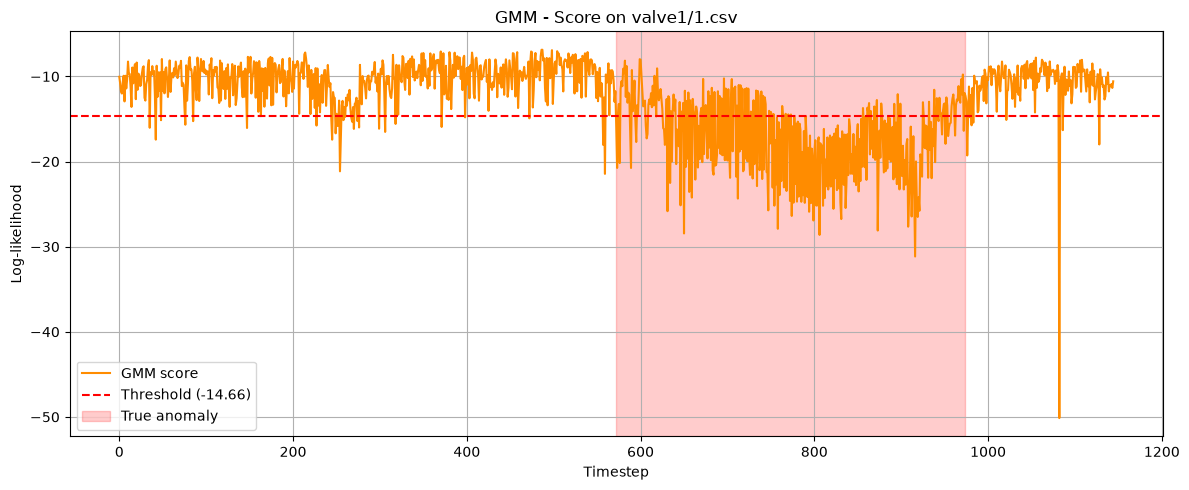

Anomaly starts at timestep: 572
First detection: 572
Delay: 0 timesteps


In [4]:
result = train_and_evaluate_gmm(all_files[1], features)

plt.figure(figsize=(12, 5))
plt.plot(result["scores"], color="darkorange", label="GMM score")
plt.axhline(y=result["threshold"], color="red", linestyle="--",
            label=f"Threshold ({result['threshold']:.2f})")
anomaly_idx = result["df"][result["df"]["anomaly"] == 1].index
plt.axvspan(anomaly_idx[0], anomaly_idx[-1], alpha=0.2, color="red", label="True anomaly")
plt.xlabel("Timestep")
plt.ylabel("Log-likelihood")
plt.title("GMM - Score on valve1/1.csv")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Anomaly starts at timestep: {result['first_real']}")
print(f"First detection: {result['first_detected']}")
print(f"Delay: {result['delay']} timesteps")

## Interactive file explorer

Use the dropdown to inspect the GMM score on any file in the dataset.

In [ ]:
import ipywidgets as widgets
from IPython.display import display

file_options = [f"{f.split('/')[-2]}/{f.split('/')[-1]}" for f in all_files]

def plot_file(file_name):
    fpath = [f for f in all_files if file_name in f][0]
    res = train_and_evaluate_gmm(fpath, features)
    scores = res["scores"]
    threshold = res["threshold"]
    df = res["df"]
    anomaly_idx = df[df["anomaly"] == 1].index

    plt.figure(figsize=(12, 4))
    plt.plot(scores, color="darkorange", linewidth=0.8, label="GMM score")
    plt.axhline(y=threshold, color="red", linestyle="--", label=f"Threshold ({threshold:.2f})")
    plt.axvspan(anomaly_idx[0], anomaly_idx[-1], alpha=0.2, color="red", label="True anomaly")
    if res["first_detected"] is not None:
        plt.axvline(x=res["first_detected"], color="orange", linestyle="--",
                    label=f"First detection (t={res['first_detected']}, delay={res['delay']}")
    plt.xlabel("Timestep")
    plt.ylabel("Log-likelihood")
    plt.title(f"GMM - {file_name}")
    plt.legend(fontsize=8)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

dropdown = widgets.Dropdown(options=file_options, description="File:")
widgets.interact(plot_file, file_name=dropdown)

interactive(children=(Dropdown(description='File:', options=('valve1/0.csv', 'valve1/1.csv', 'valve1/10.csv', …

<function __main__.plot_file(file_name)>

## Detection delay visualisation

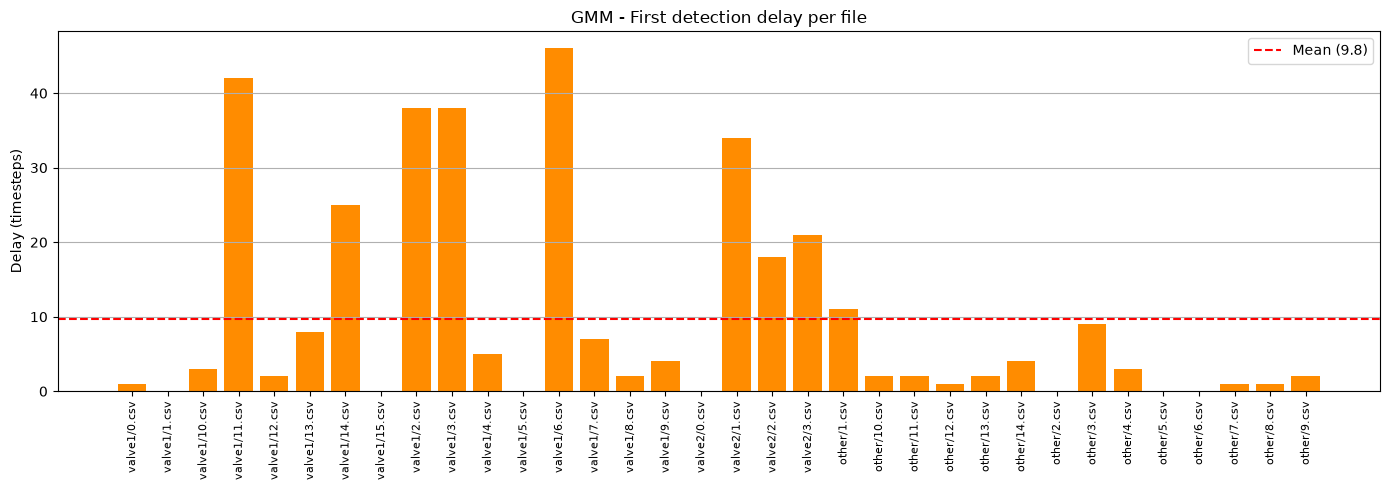

In [6]:
plt.figure(figsize=(14, 5))
plt.bar(df_results_gmm["file"], df_results_gmm["delay"], color="darkorange")
plt.xticks(rotation=90, fontsize=8)
plt.ylabel("Delay (timesteps)")
plt.title("GMM - First detection delay per file")
plt.axhline(y=df_results_gmm["delay"].mean(), color="red", linestyle="--",
            label=f"Mean ({df_results_gmm['delay'].mean():.1f})")
plt.legend()
plt.grid(axis="y")
plt.tight_layout()
plt.show()